In [ ]:
import json
import matplotlib.pyplot as plt
from PIL import Image
import io

# 1. Load Data
try:
    with open('data.json', 'r') as file:
        user_data = json.load(file)
        
    model_labels = list(user_data['model'].keys())
    model_scores = list(user_data['model'].values())
    language_labels = list(user_data['languages'].keys())
    language_scores = list(user_data['languages'].values())
    print("Data loaded.")
except FileNotFoundError:
    print("Error")

✅ Cell 1 Complete: Data loaded.


In [ ]:
# 2. Chart Generator Functions

# Strong neon pixel-art color palette
gridspec_kw={'width_ratios': [1.2, 1.2, 1]}
neon_colors = ['#FF0055', '#00FFFF', '#39FF14', '#FFFF00', '#FF6600', '#B026FF', '#FF00FF', '#0066FF']

def create_stacked_bar_chart(labels, values, width_px, height_px):
    fig, ax = plt.subplots(figsize=(width_px/100, height_px/100), dpi=100)
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)
    
    # Calculate percentages
    total = sum(values)
    left_tracker = 0
    
    # bar
    for i, (label, val) in enumerate(zip(labels, values)):
        color = neon_colors[i % len(neon_colors)]
        percentage = val / total
        ax.barh([0], [percentage], left=[left_tracker], color=color, height=0.3, edgecolor='black', linewidth=1.5)
        left_tracker += percentage

    # Remove borders and axes
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, 0.5)
    
    handles = [plt.Rectangle((0,0),1,1, color=neon_colors[i % len(neon_colors)]) for i in range(len(labels))]
    ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.3), 
              ncol=4, frameon=False, labelcolor='white', prop={'size': 9, 'weight': 'bold'})
    
    plt.tight_layout(pad=0.2)
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', transparent=True, bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    plt.close()
    return Image.open(buf)

def create_three_column_pie_chart(labels, values, width_px, height_px):
    # 1. SETUP GRID: [1, 1, 1.2] creates 3 evenly spaced columns (with a tiny bit extra room for the pie)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(width_px/100, height_px/100), dpi=100, 
                                        gridspec_kw={'width_ratios': [1, 1, 1.2]})
    fig.patch.set_alpha(0.0)
    
    for ax in [ax1, ax2, ax3]:
        ax.patch.set_alpha(0.0)
        ax.axis('off')
        
    # 2. Pie Chart
    wedges, texts = ax3.pie(
        values, 
        colors=neon_colors,
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
        radius=1.1 
    )
    
    # 3. Legends
    leg_style = {'frameon': False, 'labelcolor': 'white', 'handletextpad': 0.5,
                 'loc': 'center', 'prop': {'size': 9, 'weight': 'bold'}}

    # Legend Col 1 (Centered in Left box)
    ax1.legend(wedges[:3], labels[:3], **leg_style)

    # Legend Col 2 (Centered in Middle box)
    if len(labels) > 3:
         ax2.legend(wedges[3:], labels[3:], **leg_style)
    
    plt.tight_layout(pad=0)
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', transparent=True, bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    plt.close()
    return Image.open(buf)


print("complete")

✅ Cell 2 Complete: Neon chart engines locked in.


In [ ]:
# 3. Generate Charts
# Languages
left_chart_img = create_stacked_bar_chart(language_labels, language_scores, 480, 135)

# Models
right_chart_img = create_three_column_pie_chart(model_labels, model_scores, 480, 135)

print(f"complete")

✅ Cell 3 Complete: Charts generated!


✅ Cell 4 Complete: SUCCESS! Saved as 'final_github_banner.png'


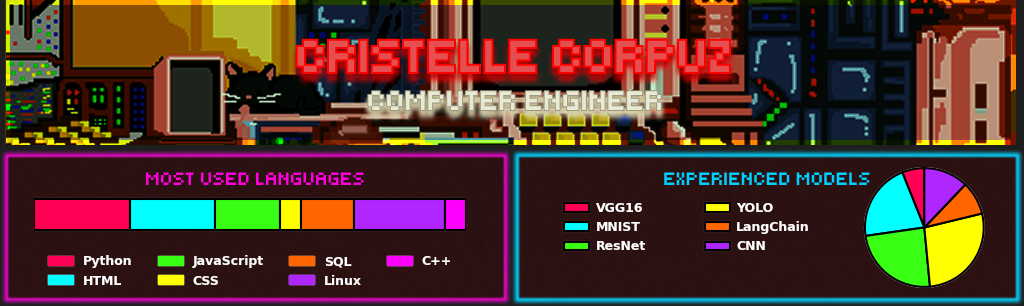

In [ ]:
# 4. Final Image
try:
    base_image = Image.open('main banner.png').convert('RGBA')

    left_x = int((501 - left_chart_img.width) / 2)
    left_y = 155 + int((145 - left_chart_img.height) / 2)

    right_x = 511 + int((501 - right_chart_img.width) / 2)
    right_y = 155 + int((145 - right_chart_img.height) / 2)

    base_image.paste(left_chart_img, (left_x, left_y), left_chart_img)
    base_image.paste(right_chart_img, (right_x, right_y), right_chart_img)

    base_image.save('final_github_banner.png')
    print("complete")

    display(base_image)
    
except FileNotFoundError:
    print("error.")